# 1) Import libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt


# 2) Display and style settings


In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("Libraries loaded successfully!")


Libraries loaded successfully!


 # 3) Load dataset


In [9]:
file_path=r'D:\Proje\retail-sales-customer-behavior-analysis\data\raw\Online Retail.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')
print("Dataset loaded successfully!")
df.head()


Dataset loaded successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


# 4) Basic data check


In [10]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:")
df.info()


Shape: (541909, 8)

Columns:
 Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# 5) Handle date column correctly


In [12]:
# تغییر فرمت به %y (دو رقمی)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')

print("InvoiceDate converted to datetime successfully!")
df.head()



InvoiceDate converted to datetime successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# 6) Data cleaning


In [13]:
# حذف مقادیر خالی در CustomerID
df = df.dropna(subset=['CustomerID']).copy()

# حذف فاکتورهای کنسلی
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()

# حذف مقادیر منفی یا صفر در Quantity و UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

print("Data cleaned successfully!")
print("New shape:", df.shape)
df.head()


Data cleaned successfully!
New shape: (397884, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


7) Feature Engineering


In [14]:
# ساخت TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# ساخت InvoiceMonth
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

# ساخت CohortMonth
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

print("Feature engineering completed!")
df[['CustomerID', 'InvoiceDate', 'InvoiceMonth', 'CohortMonth', 'TotalPrice']].head()



Feature engineering completed!


,CustomerID,InvoiceDate,InvoiceMonth,CohortMonth,TotalPrice
0,17850.0,2010-12-01 08:26:00,2010-12-01,2010-12-01,15.30
1,17850.0,2010-12-01 08:26:00,2010-12-01,2010-12-01,20.34
2,17850.0,2010-12-01 08:26:00,2010-12-01,2010-12-01,22.00
3,17850.0,2010-12-01 08:26:00,2010-12-01,2010-12-01,20.34
4,17850.0,2010-12-01 08:26:00,2010-12-01,2010-12-01,20.34


# 8) Create CohortIndex


In [16]:
invoice_year = df['InvoiceMonth'].dt.year
invoice_month = df['InvoiceMonth'].dt.month

cohort_year = df['CohortMonth'].dt.year
cohort_month = df['CohortMonth'].dt.month

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

df['CohortIndex'] = years_diff * 12 + months_diff + 1

print("CohortIndex created successfully!")
df[['CustomerID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].head(10)



CohortIndex created successfully!


,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,17850.0,2010-12-01,2010-12-01,1
1,17850.0,2010-12-01,2010-12-01,1
2,17850.0,2010-12-01,2010-12-01,1
3,17850.0,2010-12-01,2010-12-01,1
4,17850.0,2010-12-01,2010-12-01,1
5,17850.0,2010-12-01,2010-12-01,1
6,17850.0,2010-12-01,2010-12-01,1
7,17850.0,2010-12-01,2010-12-01,1
8,17850.0,2010-12-01,2010-12-01,1
9,13047.0,2010-12-01,2010-12-01,1


# 9) Create cohort table


In [17]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

cohort_sizes = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(cohort_sizes, axis=0)

print("Cohort matrix created successfully!")
retention.head()


Cohort matrix created successfully!


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02-01,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03-01,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04-01,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


# 10) Convert retention to percentage


In [18]:
retention_percentage = retention * 100
retention_percentage.round(1)


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02-01,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03-01,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04-01,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05-01,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,17.4,15.7,26.4,23.1,33.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,18.1,20.7,22.3,27.1,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,20.7,24.9,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 11) Plot retention heatmap


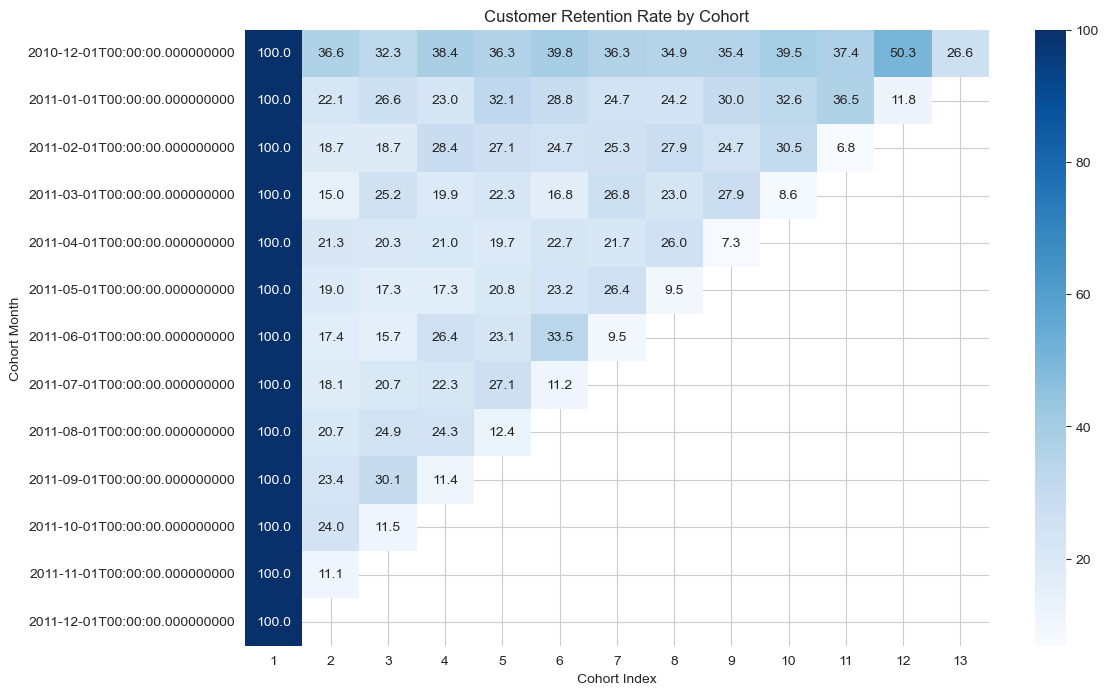

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(retention_percentage, annot=True, fmt='.1f', cmap='Blues')
plt.title('Customer Retention Rate by Cohort')
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index')
plt.show()


# 12)save cleaned dataset

In [20]:
df.to_csv('online_retail_cleaned_with_cohort.csv', index=False, encoding='utf-8-sig')
print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!
